In [2]:
import pandas as pd

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Modelos import RandomForestModel
from Estrategia import EstrategiaMLEquiponderada
from Backtest import BacktestEngine

In [3]:
csv_path = r"c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

In [4]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio="mediana", ticker_indice="SPY")
modelo = RandomForestModel(positive_class_weight=1.5, n_estimators=700, max_depth=6)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=11, umbral_salida=22)

[*********************100%***********************]  42 of 42 completed
[*********************100%***********************]  42 of 42 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  42 of 42 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Doc

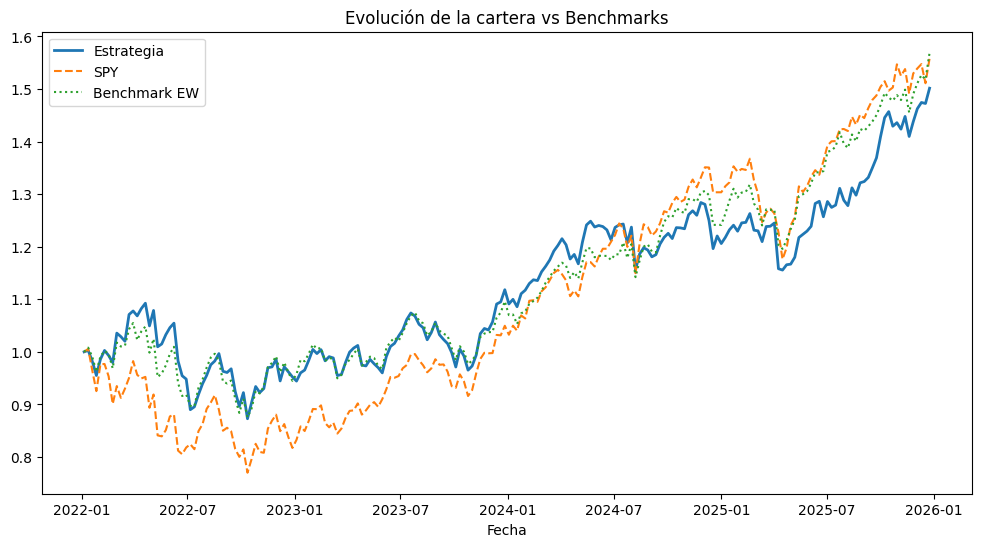

,Estrategia,SPY,Benchmark EW
Rentabilidad total,50.15%,55.82%,56.90%
Rentabilidad anualizada,10.75%,11.79%,11.98%
Volatilidad anualizada,15.40%,16.44%,14.21%
Sharpe,0.74,0.76,0.87
Sortino,1.02,1.05,1.20
Max Drawdown,-20.11%,-23.42%,-16.98%
Calmar,0.53,0.50,0.71
Win rate,60.87%,60.39%,60.87%
Mejor periodo,5.73%,5.70%,5.06%
Peor periodo,-6.98%,-8.46%,-7.08%


In [5]:
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2017-01-01",
    end_date="2026-01-01",
    len_ventana=5,
    nominal=10000000
)

engine.print_results(bmks=["SPY"], bmk_equal_weight=tickers)

In [8]:
import numpy as np
import pandas as pd
import itertools

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Modelos import RandomForestModel
from Estrategia import EstrategiaMLEquiponderada
from Backtest import BacktestEngine

import warnings
warnings.filterwarnings("ignore")

class CachedYFinanceProvider(YFinanceProvider):
    def __init__(self):
        self._cache_daily = {}
        self._cache_weekly = {}

    @staticmethod
    def _key(tickers, start_date, end_date):
        if isinstance(tickers, str):
            t = (tickers,)
        else:
            t = tuple(sorted(tickers))
        return (t, str(start_date), str(end_date))

    def download_prices_daily(self, tickers, start_date, end_date):
        k = self._key(tickers, start_date, end_date)
        if k not in self._cache_daily:
            self._cache_daily[k] = super().download_prices_daily(tickers, start_date, end_date)
        return self._cache_daily[k].copy()

    def download_prices_weekly(self, tickers, start_date, end_date):
        k = self._key(tickers, start_date, end_date)
        if k not in self._cache_weekly:
            self._cache_weekly[k] = super().download_prices_weekly(tickers, start_date, end_date)
        return self._cache_weekly[k].copy()

def perf_metrics(level_series, periods_per_year=52):
    r = level_series.dropna().pct_change().dropna()
    total = (1 + r).prod() - 1
    ann = (1 + total) ** (periods_per_year / len(r)) - 1
    vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() * periods_per_year) / vol
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = dd.min()
    calmar = ann / abs(mdd)
    return {
        "Total Return": total,
        "CAGR": ann,
        "Vol": vol,
        "Sharpe": sharpe,
        "MaxDD": mdd,
        "Calmar": calmar
    }

def run_config(cfg, tickers, proveedor, start_date="2014-01-01", end_date="2020-01-01", nominal=10_000_000):
    universo = UniversoActivosEstatico(tickers=tickers)
    fe = FeatureEngineer(criterio=cfg["criterio"], ticker_indice="SPY")
    modelo = RandomForestModel(
        positive_class_weight=cfg["positive_class_weight"],
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"]
    )
    estrategia = EstrategiaMLEquiponderada(
        modelo=modelo,
        n_activos_obj=cfg["n_activos_obj"],
        umbral_salida=cfg["umbral_salida"]
    )

    engine = BacktestEngine(
        universo=universo,
        proveedor=proveedor,
        feature_engineer=fe,
        estrategia=estrategia,
        start_date=start_date,
        end_date=end_date,
        len_ventana=cfg["len_ventana"],
        nominal=nominal
    )

    bt_df = engine._run()
    if bt_df.empty:
        out = {**cfg}
        out.update({
            "Strat_CAGR": np.nan, "Strat_Sharpe": np.nan, "Strat_MaxDD": np.nan, "Strat_Calmar": np.nan,
            "EW_CAGR": np.nan, "EW_Sharpe": np.nan, "EW_MaxDD": np.nan,
            "CAGR_Alpha_vs_EW": np.nan, "Sharpe_Diff_vs_EW": np.nan,
            "status": "empty_backtest"
        })
        return out

    bt = bt_df.set_index("Fecha")["Valor cartera"]
    bt = bt / bt.iloc[0]
    m_strat = perf_metrics(bt)

    df_ew = proveedor.download_prices_daily(tickers, start_date, end_date)
    precios = (
        df_ew.assign(Fecha=pd.to_datetime(df_ew["Fecha"]))
        .pivot(index="Fecha", columns="Ticker", values="Precio_Close")
        .sort_index()
    )
    ew = (1 + precios.pct_change().mean(axis=1, skipna=True).fillna(0)).cumprod()
    ew = ew.reindex(bt.index).ffill()
    ew = ew / ew.iloc[0]
    m_ew = perf_metrics(ew)

    out = {**cfg}
    out.update({
        "Strat_CAGR": m_strat["CAGR"],
        "Strat_Sharpe": m_strat["Sharpe"],
        "Strat_MaxDD": m_strat["MaxDD"],
        "Strat_Calmar": m_strat["Calmar"],
        "EW_CAGR": m_ew["CAGR"],
        "EW_Sharpe": m_ew["Sharpe"],
        "EW_MaxDD": m_ew["MaxDD"],
        "CAGR_Alpha_vs_EW": m_strat["CAGR"] - m_ew["CAGR"],
        "Sharpe_Diff_vs_EW": m_strat["Sharpe"] - m_ew["Sharpe"],
    })
    return out

proveedor_cache = CachedYFinanceProvider()

# --- 1) Grid local denso alrededor de la mejor config ---
base_cfg = {
    "criterio": "mediana",
    "len_ventana": 5,
    "n_activos_obj": 12,
    "umbral_salida": 20,
    "positive_class_weight": 1.0,
    "n_estimators": 300,
    "max_depth": 8,
}

local_grid = {
    "criterio": [base_cfg["criterio"]],                      # fijamos mediana
    "len_ventana": [4, 5, 6],
    "n_activos_obj": [10, 11, 12, 13, 14],
    "umbral_salida": [18, 20, 22, 24],
    "positive_class_weight": [0.5, 1.0, 1.5, 2.0],
    "n_estimators": [200, 300, 400, 500, 700],
    "max_depth": [6, 8, 10],
}

all_cfgs = [
    dict(zip(local_grid.keys(), values))
    for values in itertools.product(*local_grid.values())
]

print(f"Combinaciones totales del grid local: {len(all_cfgs)}")

# --- 2) Cap de ejecucion para no tardar demasiado ---
# Ajusta este numero segun tiempo disponible (ej: 120, 200, 300)
MAX_RUNS = 220
rng = np.random.default_rng(42)

if len(all_cfgs) > MAX_RUNS:
    idx = rng.choice(len(all_cfgs), size=MAX_RUNS, replace=False)
    cfgs_to_run = [all_cfgs[i] for i in idx]
else:
    cfgs_to_run = all_cfgs

print(f"Combinaciones a ejecutar: {len(cfgs_to_run)}")

# --- 3) Ejecutar ---
rows = []
for i, cfg in enumerate(cfgs_to_run, 1):
    if i % 20 == 0 or i == 1 or i == len(cfgs_to_run):
        print(f"[{i}/{len(cfgs_to_run)}] {cfg}")
    rows.append(
        run_config(
            cfg,
            tickers=tickers,
            proveedor=proveedor_cache,
            start_date="2014-01-01",
            end_date="2020-01-01"
        )
    )

results_local = pd.DataFrame(rows)

# --- 4) Ranking principal (igual que antes) ---
leaderboard_local = results_local.sort_values(
    by=["Strat_Sharpe", "CAGR_Alpha_vs_EW", "Strat_MaxDD"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    leaderboard_local.head(25).style.format({
        "Strat_CAGR": "{:.2%}",
        "Strat_MaxDD": "{:.2%}",
        "EW_CAGR": "{:.2%}",
        "EW_MaxDD": "{:.2%}",
        "CAGR_Alpha_vs_EW": "{:.2%}",
        "Strat_Sharpe": "{:.2f}",
        "EW_Sharpe": "{:.2f}",
        "Sharpe_Diff_vs_EW": "{:.2f}",
        "Strat_Calmar": "{:.2f}",
    })
)

# --- 5) Filtro de robustez (alpha>0, sharpe>=EW, DD no peor que EW) ---
robust = results_local[
    (results_local["CAGR_Alpha_vs_EW"] > 0) &
    (results_local["Sharpe_Diff_vs_EW"] >= 0) &
    (results_local["Strat_MaxDD"].abs() <= results_local["EW_MaxDD"].abs())
].copy()

robust = robust.sort_values(
    by=["Strat_Sharpe", "CAGR_Alpha_vs_EW"],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Configs robustas encontradas: {len(robust)}")

display(
    robust.head(20).style.format({
        "Strat_CAGR": "{:.2%}",
        "Strat_MaxDD": "{:.2%}",
        "EW_CAGR": "{:.2%}",
        "EW_MaxDD": "{:.2%}",
        "CAGR_Alpha_vs_EW": "{:.2%}",
        "Strat_Sharpe": "{:.2f}",
        "EW_Sharpe": "{:.2f}",
        "Sharpe_Diff_vs_EW": "{:.2f}",
        "Strat_Calmar": "{:.2f}",
    })
)

# Opcional: guardar resultados
# results_local.to_csv("grid_local_results.csv", index=False)
# robust.to_csv("grid_local_robust.csv", index=False)

[***                    7%                       ]  3 of 42 completed

Combinaciones totales del grid local: 3600
Combinaciones a ejecutar: 220
[1/220] {'criterio': 'mediana', 'len_ventana': 4, 'n_activos_obj': 11, 'umbral_salida': 18, 'positive_class_weight': 2.0, 'n_estimators': 200, 'max_depth': 6}


[*******************   40%                       ]  17 of 42 completed$SEA: possibly delisted; no price data found  (1d 2014-01-01 -> 2020-01-01) (Yahoo error = "Data doesn't exist for startDate = 1388552400, endDate = 1577854800")
[*********************100%***********************]  42 of 42 completed

1 Failed download:
['SEA']: possibly delisted; no price data found  (1d 2014-01-01 -> 2020-01-01) (Yahoo error = "Data doesn't exist for startDate = 1388552400, endDate = 1577854800")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to si

[20/220] {'criterio': 'mediana', 'len_ventana': 6, 'n_activos_obj': 14, 'umbral_salida': 22, 'positive_class_weight': 1.5, 'n_estimators': 300, 'max_depth': 8}


c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\VariablesTransformation.py:121: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker", group_keys=False).apply(add_bollinger)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)

...

[220/220] {'criterio': 'mediana', 'len_ventana': 5, 'n_activos_obj': 12, 'umbral_salida': 22, 'positive_class_weight': 2.0, 'n_estimators': 700, 'max_depth': 10}


c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\VariablesTransformation.py:121: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Ticker", group_keys=False).apply(add_bollinger)


,criterio,len_ventana,n_activos_obj,umbral_salida,positive_class_weight,n_estimators,max_depth,Strat_CAGR,Strat_Sharpe,Strat_MaxDD,Strat_Calmar,EW_CAGR,EW_Sharpe,EW_MaxDD,CAGR_Alpha_vs_EW,Sharpe_Diff_vs_EW,status
0,mediana,5,11,18,1.000000,500,8,23.53%,2.19,-5.06%,4.65,22.46%,2.10,-5.16%,1.08%,0.08,nan
1,mediana,5,10,18,1.000000,500,8,23.15%,2.16,-4.99%,4.64,22.46%,2.10,-5.16%,0.69%,0.06,nan
2,mediana,5,11,22,1.500000,700,6,24.34%,2.15,-4.90%,4.96,22.46%,2.10,-5.16%,1.88%,0.05,nan
3,mediana,5,11,20,1.000000,700,6,23.68%,2.11,-5.08%,4.66,22.46%,2.10,-5.16%,1.23%,0.00,nan
4,mediana,5,11,24,1.000000,500,6,23.17%,2.10,-4.67%,4.96,22.46%,2.10,-5.16%,0.72%,-0.00,nan
5,mediana,5,13,20,1.500000,400,6,24.54%,2.09,-5.23%,4.69,22.46%,2.10,-5.16%,2.08%,-0.02,nan
6,mediana,5,14,24,1.000000,400,8,21.42%,2.09,-4.84%,4.43,22.46%,2.10,-5.16%,-1.03%,-0.02,nan
7,mediana,5,13,18,1.500000,200,10,22.70%,2.08,-4.86%,4.67,22.46%,2.10,-5.16%,0.24%,-0.03,nan
8,mediana,5,11,18,1.500000,500,10,22.31%,2.07,-5.07%,4.40,22.46%,2.10,-5.16%,-0.14%,-0.03,nan
9,mediana,5,14,24,1.500000,300,6,23.89%,2.04,-5.08%,4.70,22.46%,2.10,-5.16%,1.44%,-0.06,nan


Configs robustas encontradas: 22


,criterio,len_ventana,n_activos_obj,umbral_salida,positive_class_weight,n_estimators,max_depth,Strat_CAGR,Strat_Sharpe,Strat_MaxDD,Strat_Calmar,EW_CAGR,EW_Sharpe,EW_MaxDD,CAGR_Alpha_vs_EW,Sharpe_Diff_vs_EW,status
0,mediana,5,11,18,1.000000,500,8,23.53%,2.19,-5.06%,4.65,22.46%,2.10,-5.16%,1.08%,0.08,nan
1,mediana,5,10,18,1.000000,500,8,23.15%,2.16,-4.99%,4.64,22.46%,2.10,-5.16%,0.69%,0.06,nan
2,mediana,5,11,22,1.500000,700,6,24.34%,2.15,-4.90%,4.96,22.46%,2.10,-5.16%,1.88%,0.05,nan
3,mediana,5,11,20,1.000000,700,6,23.68%,2.11,-5.08%,4.66,22.46%,2.10,-5.16%,1.23%,0.00,nan
4,mediana,4,12,24,0.500000,400,10,8.33%,0.66,-13.79%,0.60,4.25%,0.42,-14.70%,4.08%,0.25,nan
5,mediana,4,11,20,1.000000,300,8,7.81%,0.66,-13.90%,0.56,4.25%,0.42,-14.70%,3.56%,0.24,nan
6,mediana,4,11,24,0.500000,200,10,7.59%,0.62,-13.63%,0.56,4.25%,0.42,-14.70%,3.34%,0.21,nan
7,mediana,4,11,24,1.000000,200,6,7.02%,0.61,-13.46%,0.52,4.25%,0.42,-14.70%,2.77%,0.19,nan
8,mediana,4,13,20,0.500000,300,8,6.87%,0.56,-13.74%,0.50,4.25%,0.42,-14.70%,2.62%,0.15,nan
9,mediana,4,12,24,1.000000,400,8,6.11%,0.54,-14.66%,0.42,4.25%,0.42,-14.70%,1.86%,0.13,nan
